In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time

## Ceny używanych samochodów

https://www.kaggle.com/adityadesai13/used-car-dataset-ford-and-mercedes

Used cars prices dataset. 

In [2]:
raw_data = pd.read_csv('merc.csv')
raw_data.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,SLK,2005,5200,Automatic,63000,Petrol,325,32.1,1.8
1,S Class,2017,34948,Automatic,27000,Hybrid,20,61.4,2.1
2,SL CLASS,2016,49948,Automatic,6200,Petrol,555,28.0,5.5
3,G Class,2016,61948,Automatic,16000,Petrol,325,30.4,4.0
4,G Class,2016,73948,Automatic,4000,Petrol,325,30.1,4.0


### Przegląd danych

In [3]:
raw_data.describe()

,year,price,mileage,tax,mpg,engineSize
count,13119.000000,13119.000000,13119.000000,13119.000000,13119.000000,13119.000000
mean,2017.296288,24698.596920,21949.559037,129.972178,55.155843,2.071530
std,2.224709,11842.675542,21176.512267,65.260286,15.220082,0.572426
min,1970.000000,650.000000,1.000000,0.000000,1.100000,0.000000
25%,2016.000000,17450.000000,6097.500000,125.000000,45.600000,1.800000
50%,2018.000000,22480.000000,15189.000000,145.000000,56.500000,2.000000
75%,2019.000000,28980.000000,31779.500000,145.000000,64.200000,2.100000
max,2020.000000,159999.000000,259000.000000,580.000000,217.300000,6.200000


In [4]:
raw_data['model'].value_counts()

model
 C Class      3747
 A Class      2561
 E Class      1953
 GLC Class     960
 GLA Class     847
 B Class       591
 CL Class      511
 GLE Class     461
 SL CLASS      260
 CLS Class     237
 V Class       207
 S Class       197
 GL Class      121
 SLK            95
 CLA Class      86
 X-CLASS        82
 M Class        79
 GLS Class      74
 GLB Class      19
 G Class        15
 CLK             7
 CLC Class       3
 R Class         2
180              1
230              1
220              1
200              1
Name: count, dtype: int64

In [5]:
raw_data['transmission'].value_counts()

transmission
Semi-Auto    6848
Automatic    4825
Manual       1444
Other           2
Name: count, dtype: int64

In [6]:
raw_data['fuelType'].value_counts()

fuelType
Diesel    9187
Petrol    3752
Hybrid     173
Other        7
Name: count, dtype: int64

In [7]:
raw_data['engineSize'].value_counts()

engineSize
2.1    4018
2.0    3739
1.5    1675
3.0    1355
1.6     843
1.3     716
4.0     197
2.2     124
2.9     120
1.8     113
2.3      73
5.5      44
4.7      24
3.5      19
6.2      13
3.2      13
0.0      12
5.0       6
2.7       5
6.0       2
3.7       2
1.7       2
2.5       1
5.4       1
4.3       1
1.4       1
Name: count, dtype: int64

## Data preprocessing

W naszych danych jest 27 modeli mercedesa. Zmniejszmy tę liczbę, definiując kategorię „other”.

In [28]:
cars = raw_data.copy()
models = raw_data['model'].value_counts()
models = models[models<150]
other_models = [x for x in models.index]
cars['model'] = cars['model'].replace(to_replace = other_models, value='Other')

sprawdzenie

In [29]:
cars['model'].value_counts()

model
 C Class      3747
 A Class      2561
 E Class      1953
 GLC Class     960
 GLA Class     847
 B Class       591
Other          587
 CL Class      511
 GLE Class     461
 SL CLASS      260
 CLS Class     237
 V Class       207
 S Class       197
Name: count, dtype: int64

Dummy variables - ile powinno być?

In [10]:
model_dummies = pd.get_dummies(cars['model'], prefix='model', drop_first=False)
transmission_dummies = pd.get_dummies(cars['transmission'], prefix='transmission', drop_first=False)
fuelType_dummies = pd.get_dummies(cars['fuelType'], prefix='fuelType', drop_first=False)

In [11]:
cars1 = pd.concat([cars, model_dummies, transmission_dummies, fuelType_dummies], axis=1)

In [12]:
cars1.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,model_ A Class,...,model_ V Class,model_Other,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Diesel,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,Other,2005,5200,Automatic,63000,Petrol,325,32.1,1.8,False,...,False,True,True,False,False,False,False,False,False,True
1,S Class,2017,34948,Automatic,27000,Hybrid,20,61.4,2.1,False,...,False,False,True,False,False,False,False,True,False,False
2,SL CLASS,2016,49948,Automatic,6200,Petrol,555,28.0,5.5,False,...,False,False,True,False,False,False,False,False,False,True
3,Other,2016,61948,Automatic,16000,Petrol,325,30.4,4.0,False,...,False,True,True,False,False,False,False,False,False,True
4,Other,2016,73948,Automatic,4000,Petrol,325,30.1,4.0,False,...,False,True,True,False,False,False,False,False,False,True


In [13]:
cars2 = cars1.drop(['model','transmission','fuelType'], axis='columns')

In [14]:
cars2.head()

,year,price,mileage,tax,mpg,engineSize,model_ A Class,model_ B Class,model_ C Class,model_ CL Class,...,model_ V Class,model_Other,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Diesel,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2005,5200,63000,325,32.1,1.8,False,False,False,False,...,False,True,True,False,False,False,False,False,False,True
1,2017,34948,27000,20,61.4,2.1,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
2,2016,49948,6200,555,28.0,5.5,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
3,2016,61948,16000,325,30.4,4.0,False,False,False,False,...,False,True,True,False,False,False,False,False,False,True
4,2016,73948,4000,325,30.1,4.0,False,False,False,False,...,False,True,True,False,False,False,False,False,False,True


In [15]:
cars2.shape

(13119, 27)

### Definiowanie zmiennych y i X, podział na zbiór treningowy i testowy

In [16]:
y = cars2['price']
X = cars2.drop(columns='price')
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Random Forest Regressor

Las losowy z parametrami domyślnymi

In [17]:
from sklearn.ensemble import RandomForestRegressor
rf1 = RandomForestRegressor()
rf1.fit(X_train,y_train)

RandomForestRegressor()

In [18]:
rf1.score(X_test,y_test)

0.9544746776746873

## Parameters of RandomForestRegressor

*  **n_estimators** - The number of trees in the forest. **Defualt value** is **100**.
*  **criterion** - one of '**squared_error**', 'absolute_error', 'poisson'
*  **max_depth** - The maximum depth of the tree.
*  **min_samples_split** - The minimum number of samples required to split an internal node. **Defualt value** is **2**.
*  **min_samples_leaf** - The minimum number of samples required to be at a leaf node. **Defualt value** is **1**, but recommended is 5.
* **max_features** - The number of features to consider when looking for the best split. One of **'auto'**, 'sqrt', 'log2'. If 'auto', then max_features=n_features (!!). Recommended value is 0.33 - 33%. 
* **bootstrap** - Whether bootstrap samples are used when building trees. **Defualt value** is **True**.
* **oob_score** - Whether to use out-of-bag samples to estimate the generalization score. **Defualt value** is **False**.


Użyjmy rekomendowanych w literaturze parametrów:  
* n_estimators = 1000
* max_depth = 15 to reduce computing time
* min_samples_leaf = 50 to reduce computing time
* max_features = 1/3

In [19]:
rf2 = RandomForestRegressor(n_estimators = 1000,max_depth = 15, min_samples_leaf = 50, max_features = 9)
rf2.fit(X_train,y_train)

RandomForestRegressor(max_depth=15, max_features=9, min_samples_leaf=50,
                      n_estimators=1000)

In [20]:
rf2.score(X_test,y_test)

0.854959063971288

### Finding the best parameters

We will find optimal number of trees by using OOB_score. This takes 2 minutes.

C:\Users\HP\anaconda3\envs\wad\lib\site-packages\sklearn\ensemble\_forest.py:615: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


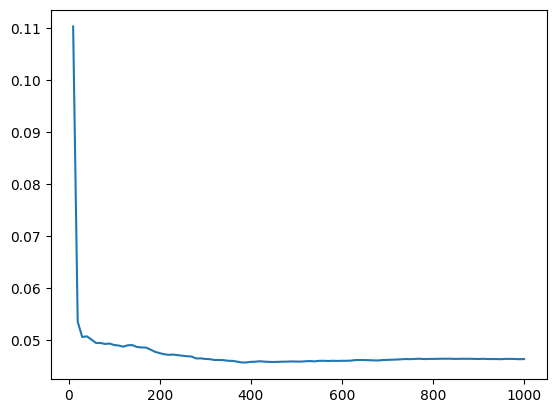

In [21]:
error_rate = []
times = []
min_estimators = 10
max_estimators = 1000

rf = RandomForestRegressor(warm_start=True, oob_score=True,
                               max_features=1/3, n_jobs=-1)

for i in range(min_estimators,max_estimators+1, 10):
    rf.set_params(n_estimators=i)
    rf.fit(X,y)
    oob_error = 1 - rf.oob_score_
    error_rate.append(oob_error)

x_axis = range(min_estimators,max_estimators+1, 10)

plt.plot(x_axis, error_rate)
plt.show()

Wydaje mi się, że wzięcie ponad 200 drzew nie poprawia modelu.

Znajdźmy najlepsze hiperparametry za pomocą losowego wyszukiwania krzyżowego. Zajmuje to około 11 minut.

In [22]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(n_estimators=200, n_jobs=-1)

param_grid = {'max_depth': [2,3,4,5,6,7,8,None], 
              'min_samples_leaf': range(5,31), 'max_features':range(2,26)
              }
rf_rscv = RandomizedSearchCV(rf, param_grid, n_iter=100, cv=5, n_jobs=-1)
rf_rscv.fit(X, y)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_estimators=200, n_jobs=-1),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_depth': [2, 3, 4, 5, 6, 7, 8,
                                                      None],
                                        'max_features': range(2, 26),
                                        'min_samples_leaf': range(5, 31)})

In [23]:
rf_rscv.best_params_

{'min_samples_leaf': 8, 'max_features': 14, 'max_depth': None}

In [24]:
rf = RandomForestRegressor(n_estimators = 200, max_features=18, min_samples_leaf=6, n_jobs=-1)
rf.fit(X_train,y_train)
rf.score(X_test,y_test)

0.9466532877913323

## Feature importance

In [25]:
X['random'] = np.random.random(size = len(X))
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

impurity-based feature importances - obliczenia zajmują 1 minutę

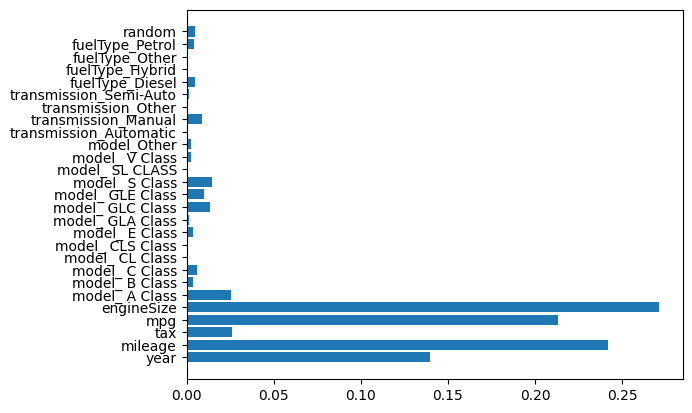

In [26]:
rf = RandomForestRegressor(n_estimators = 2000, max_features=18, min_samples_leaf=6, n_jobs=-1)
rf.fit(X,y)
feature_importances = rf.feature_importances_
plt.barh(X.columns, feature_importances)
plt.show()

Permutation variable importance measure. Około 4 minuty.

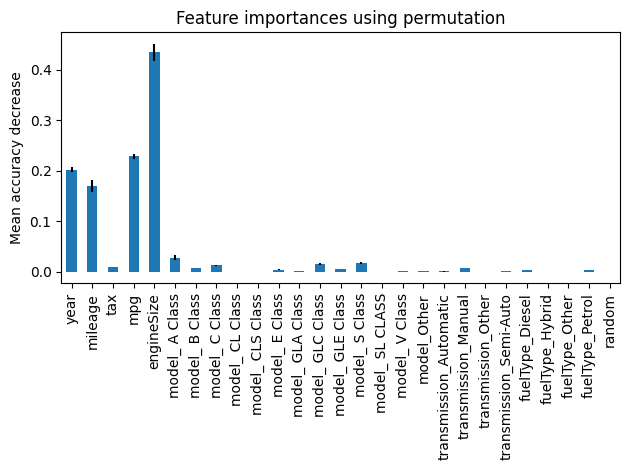

In [27]:
from sklearn.inspection import permutation_importance

rf = RandomForestRegressor(n_estimators = 2000, max_features=18, min_samples_leaf=6, n_jobs=-1)
rf.fit(X_train,y_train)

result = permutation_importance(
    rf, X_test, y_test, n_repeats=10)

forest_importances = pd.Series(result.importances_mean, index=X.columns)

fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=result.importances_std, ax=ax)
ax.set_title("Feature importances using permutation")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()